<!-- # LiH 分子 VQE 完整教程（6-Qubit）

接下来我们考虑LiH分子：
- 通过 freeze 和 remove，将 LiH 的active space encode 成 6-qubit 哈密顿量
- 构建一个 UCC-style 参数化电路
- 使用 VQE 进行参数优化并与 FCI 基准比较 -->

## 1. 参数配置与运行建议
本项目中，我们开始用6比特做LiH分子

In [1]:
from pathlib import Path
import json
import math

# Geometry / chemistry config
R = 2.2
R_UNIT = 'angstrom'
BASIS = 'sto-3g'
MULTIPLICITY = 1
CHARGE = 0

# VQE config
cfg = {
    'layers': 3,
    'shots': 4096,
    'max_iters': 10,
    'learning_rate': 0.05,
    'seed': 7,
    'gradient_method': 'autograd',
    'prefer_chips': 'Simulator',
    'shift': math.pi / 2,
}

print('R =', R, R_UNIT)
print('Basis =', BASIS)
print('VQE cfg =', cfg)

R = 2.2 angstrom
Basis = sto-3g
VQE cfg = {'layers': 3, 'shots': 4096, 'max_iters': 10, 'learning_rate': 0.05, 'seed': 7, 'gradient_method': 'autograd', 'prefer_chips': 'Simulator', 'shift': 1.5707963267948966}


默认读取文件：
- `../data/lih_R2.2_angstrom_sto-3g_6q.json`

若文件不存在，请在 WSL 中执行：
```bash
cd /mnt/d/OneDrive/work/research/code/Quantum_control
python chemistry/scripts/export_lih_terms_wsl.py --R 2.2 --unit angstrom --reduction paper --output chemistry/data/lih_R2.2_angstrom_sto-3g_6q.json
```


In [2]:
from __future__ import annotations

import os
import json
from pathlib import Path

# Work around duplicated OpenMP runtime loading on Windows notebook kernels.
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

from quantum_hw import QuantumHardwareClient
from quantum_hw.algorithms import VQERunner

json_path = Path('../data/lih_R2.2_angstrom_sto-3g_6q.json')
data = json.loads(json_path.read_text(encoding='utf-8'))

lih_constant = float(data['constant'])
lih_6q_terms = [(float(c), str(obs)) for c, obs in data['terms']]
nqubits = int(data['nqubits'])
fci_energy = float(data['fci_energy'])

print('Loaded from:', json_path)
print('nqubits:', nqubits)
print('term_count:', len(lih_6q_terms))
print('fci_energy:', fci_energy)


Loaded from: ..\data\lih_R2.2_angstrom_sto-3g_6q.json
nqubits: 6
term_count: 117
fci_energy: -7.845683623197186


## 3. 构建 LiH 专用 UCC-style Custom Ansatz

参照Nat. Phys. 20, 1240 (2024)，结合对称性限制和激发能量，只考虑UCC中的最关键项，包括

$$
a_5^\dagger a_2^\dagger a_1 a_0, \quad a_4^\dagger a_3^\dagger a_1 a_0, \quad a_5^\dagger a_4^\dagger a_1 a_0
$$

对应的UCC为

$$
U(\theta) =
\exp\left[
-i\theta_3 Y_0Y_1Y_4X_5 -i\theta_2 Y_0Y_1Y_3X_4 -i\theta_1 Y_0 Y_1 Y_2 Z_3 Z_4 X_5
\right]
$$


In [13]:
from quantum_hw import QuantumHardwareClient
from quantum_hw.algorithms import VQERunner
from quantum_hw.circuit import QuantumCircuit

def build_h2_ucc_style_symbolic_ansatz() -> QuantumCircuit:
    qc = QuantumCircuit(6)

    # -------------------------
    # Hartree–Fock reference or "singlet" reference state preparation
    # |110000> or (|110000> - |001100>)/sqrt(2)
    # -------------------------

    qc.ry("theta_0", 0)
    qc.cx(0, 1)
    qc.cx(1, 2)
    qc.cx(2, 3)

    qc.x(0)
    qc.x(1)

    qc.pauli_evolution("theta_1", "Y0 Y1 Y2 Z3 Z4 X5")
    qc.pauli_evolution("theta_2", "Y0 Y1 Y3 X4")
    qc.pauli_evolution("theta_3", "Y0 Y1 Y4 X5")
    return qc

custom_ansatz_qc = build_h2_ucc_style_symbolic_ansatz()
symbolic_params = sorted(
    [k for k, v in custom_ansatz_qc.params_value.items() if isinstance(k, str) and isinstance(v, str)]
)
print('Total gates in custom H2-UCC-style ansatz:', len(custom_ansatz_qc.gates))

Total gates in custom H2-UCC-style ansatz: 73


## 4. 运行 VQE 并验证 Ansatz

通常来说，加入更强问题结构先验的 ansatz，往往在相同预算下能得到更低误差，但并不绝对。

[vqe] prepare run: name=lih_6q_custom num_qubits=6 model=custom layers=3 shots=4096 max_iters=10
[vqe] candidate chips: ['Simulator']
[vqe] running on chip: Simulator
[vqe] start optimization: iters=10 layers=3 params=4 ansatz=custom shots=4096 shift=1.5707963267948966 gradient=autograd
[vqe] iter 0 start
[vqe] iter 0 energy=-0.650366 grad_norm=0.145606
[vqe] iter 0 new best energy=-0.650366
[vqe] iter 1 start
[vqe] iter 1 energy=-0.661433 grad_norm=0.122733
[vqe] iter 1 new best energy=-0.661433
[vqe] iter 2 start
[vqe] iter 2 energy=-0.669981 grad_norm=0.099443
[vqe] iter 2 new best energy=-0.669981
[vqe] iter 3 start
[vqe] iter 3 energy=-0.675958 grad_norm=0.076904
[vqe] iter 3 new best energy=-0.675958
[vqe] iter 4 start
[vqe] iter 4 energy=-0.679583 grad_norm=0.056925
[vqe] iter 4 new best energy=-0.679583
[vqe] iter 5 start
[vqe] iter 5 energy=-0.681352 grad_norm=0.042117
[vqe] iter 5 new best energy=-0.681352
[vqe] iter 6 start
[vqe] iter 6 energy=-0.681882 grad_norm=0.035270
[v

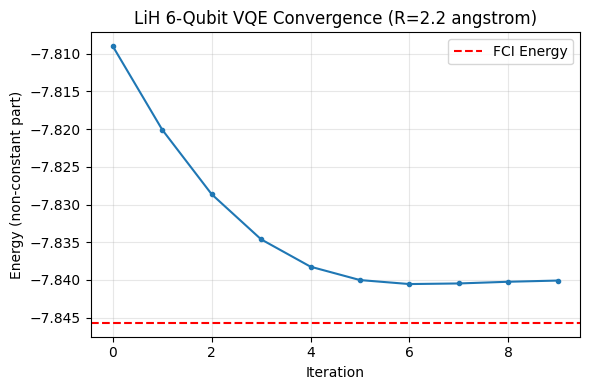

In [14]:
runner = VQERunner(
    client=QuantumHardwareClient(),
    layers=cfg['layers'],
    shots=cfg['shots'],
    max_iters=cfg['max_iters'],
    learning_rate=cfg['learning_rate'],
    gradient_method=cfg['gradient_method'],
    seed=cfg['seed'],
    shift=cfg['shift'],
)

kwargs = {
    'name': f'lih_6q_custom',
    'num_qubits': nqubits,
    'model': 'custom',
    'hamiltonian': lih_6q_terms,
    'ansatz': 'custom',
    'custom_ansatz_circuit': custom_ansatz_qc,
    'prefer_chips': cfg['prefer_chips'],
    'init_params': [0.01]*len(symbolic_params),
}

res = runner.run_model(**kwargs)
e_total = lih_constant + res.best_energy
abs_error_fci = abs(e_total - fci_energy)

print('=== 6-Qubit LiH VQE Result ===')
print('Estimated total energy:  ', round(e_total, 8))
print('FCI reference energy:    ', round(fci_energy, 8))
print('Absolute error vs FCI:   ', round(abs_error_fci, 8))

import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(6, 4))
plt.plot(np.array(res.energy_history) + lih_constant, marker='o', ms=3)
plt.axhline(fci_energy, color='red', linestyle='--', label='FCI Energy')
plt.legend()
plt.xlabel('Iteration')
plt.ylabel('Energy (non-constant part)')
plt.title(f'LiH 6-Qubit VQE Convergence (R={R} {R_UNIT})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. 在真实硬件上运行线路
结合ZNE、REM和CF

In [ ]:
cfg['prefer_chips'] = 'Baihua'
cfg['zne'] = True
cfg['readout_mitigation'] = True
cfg['clifford_fitting'] = True
cfg['clifford_fitting_num_samples'] = 8
cfg['gradient_method'] = 'parameter-shift'
from time import sleep
sleep(1500)
runner_cmp = VQERunner(
    client=QuantumHardwareClient(),
    layers=cfg['layers'],
    shots=cfg['shots'],
    max_iters=cfg['max_iters'],
    learning_rate=cfg['learning_rate'],
    gradient_method=cfg['gradient_method'],
    seed=cfg['seed'],
    zne=cfg['zne'],
    readout_mitigation=cfg['readout_mitigation'],
    shift=cfg['shift'],
    clifford_fitting=cfg['clifford_fitting'],
    clifford_fitting_num_samples=cfg['clifford_fitting_num_samples'],
)

kwargs = {
    'name': f'lih_6q_custom',
    'num_qubits': nqubits,
    'model': 'custom',
    'hamiltonian': lih_6q_terms,
    'ansatz': 'custom',
    'custom_ansatz_circuit': custom_ansatz_qc,
    'prefer_chips': cfg['prefer_chips'],
    'init_params': [0.01]*len(symbolic_params),
}

res = runner_cmp.run_model(**kwargs)
e_total = lih_constant + res.best_energy
abs_error_fci = abs(e_total - fci_energy)

print('=== 6-Qubit LiH VQE Result ===')
print('Estimated total energy:  ', round(e_total, 8))
print('FCI reference energy:    ', round(fci_energy, 8))
print('Absolute error vs FCI:   ', round(abs_error_fci, 8))

import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(6, 4))
plt.plot(np.array(res.energy_history) + lih_constant, marker='o', ms=3)
plt.axhline(fci_energy, color='red', linestyle='--', label='FCI Energy')
plt.legend()
plt.xlabel('Iteration')
plt.ylabel('Energy (non-constant part)')
plt.title(f'LiH VQE Convergence (R={R} {R_UNIT})')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. 计算完整的能量曲线

In [9]:
R_range = np.arange(0.5, 3.01, 0.3)
energy_ucc = []
cfg['gradient_method'] = 'autograd'
for r, R in enumerate(R_range):
    json_path = Path(f'../data/lih_R{R:.1f}_angstrom_sto-3g_6q.json')
    data = json.loads(json_path.read_text(encoding='utf-8'))

    lih_constant = float(data['constant'])
    lih_6q_terms = [(float(c), str(obs)) for c, obs in data['terms']]
    nqubits = int(data['nqubits'])
    fci_energy = float(data['fci_energy'])

    runner = VQERunner(
        client=QuantumHardwareClient(),
        layers=cfg['layers'],
        shots=cfg['shots'],
        max_iters=cfg['max_iters'],
        learning_rate=cfg['learning_rate'],
        gradient_method=cfg['gradient_method'],
        seed=cfg['seed'],
        shift=cfg['shift'],
    )

    kwargs = {
        'name': f'lih_6q_custom_R{R:.1f}',
        'num_qubits': nqubits,
        'model': 'custom',
        'hamiltonian': lih_6q_terms,
        'ansatz': 'custom',
        'custom_ansatz_circuit': custom_ansatz_qc,
        'prefer_chips': cfg['prefer_chips'],
        'init_params': [0]*len(symbolic_params),
    }

    res = runner.run_model(**kwargs)
    e_total = lih_constant + res.best_energy
    abs_error_fci = abs(e_total - fci_energy)
    energy_ucc.append({
        'R': R,
        'e_total': e_total,
    })


[vqe] prepare run: name=lih_6q_custom_R0.5 num_qubits=6 model=custom layers=3 shots=4096 max_iters=10
[vqe] candidate chips: ['Simulator']
[vqe] running on chip: Simulator
[vqe] start optimization: iters=10 layers=3 params=4 ansatz=custom shots=4096 shift=1.5707963267948966 gradient=autograd
[vqe] iter 0 start
[vqe] iter 0 energy=-0.945388 grad_norm=0.114512
[vqe] iter 0 new best energy=-0.945388
[vqe] iter 1 start
[vqe] iter 1 energy=-0.952188 grad_norm=0.074446
[vqe] iter 1 new best energy=-0.952188
[vqe] iter 2 start
[vqe] iter 2 energy=-0.955303 grad_norm=0.039087
[vqe] iter 2 new best energy=-0.955303
[vqe] iter 3 start
[vqe] iter 3 energy=-0.955723 grad_norm=0.021248
[vqe] iter 3 new best energy=-0.955723
[vqe] iter 4 start
[vqe] iter 4 energy=-0.955048 grad_norm=0.032464
[vqe] iter 5 start
[vqe] iter 5 energy=-0.954332 grad_norm=0.046589
[vqe] iter 6 start
[vqe] iter 6 energy=-0.954050 grad_norm=0.053932
[vqe] iter 7 start
[vqe] iter 7 energy=-0.954220 grad_norm=0.054402
[vqe] i

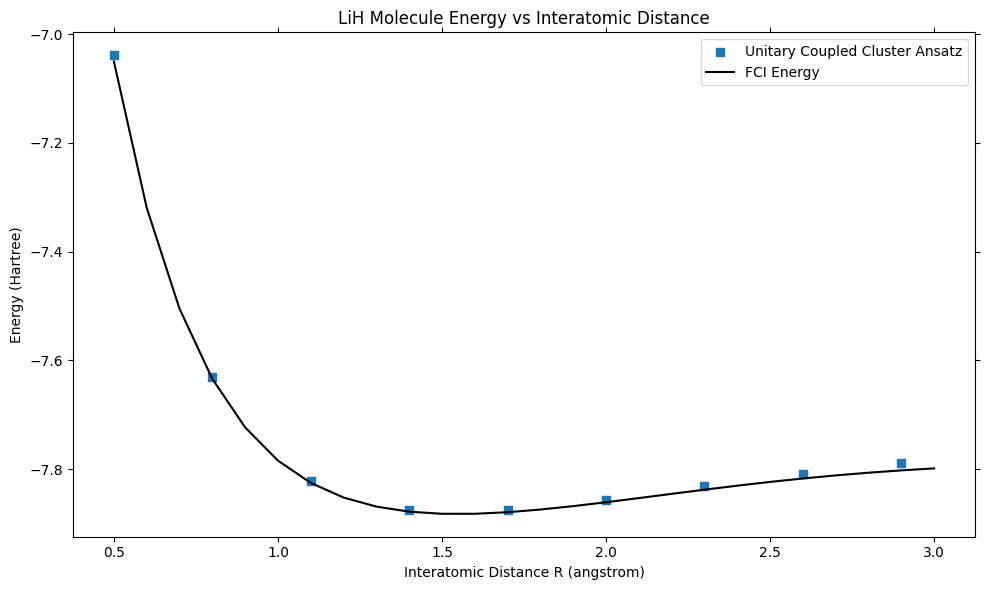

In [10]:
from matplotlib import pyplot as plt

R_values = [res['R'] for res in energy_ucc]
estimated_energies_ucc = [res['e_total'] for res in energy_ucc]
R_range = np.arange(0.5, 3.01, 0.1)
fci_energies = []
for R in R_range:
    json_path = Path(f'../data/lih_R{R:.1f}_angstrom_sto-3g_6q.json')
    data = json.loads(json_path.read_text(encoding='utf-8'))
    fci_energies.append(float(data['fci_energy']))
plt.figure(figsize=(10, 6))
plt.scatter(R_values, estimated_energies_ucc, marker='s', label='Unitary Coupled Cluster Ansatz')
plt.plot(R_range, fci_energies, 'k-', label='FCI Energy')
plt.xlabel('Interatomic Distance R (angstrom)')
plt.ylabel('Energy (Hartree)')
plt.legend()
plt.title('LiH Molecule Energy vs Interatomic Distance')
plt.tick_params(right=True, top=True)
plt.tight_layout()
plt.show()